<a href="https://colab.research.google.com/github/osalex800/Analisis-y-visualizacion-de-datos/blob/main/Practica_Unidad5_DDDM_Oscar_Alexander_Colorado_Morales_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica Unidad 5: Toma de Decisiones Basada en Datos

**Materia:** Análisis y Visualización de Datos  
**Herramientas:** R y Power BI  
**Base de datos:** `Base_Datos_Unidad5_DDDM(1).xlsx`  
**Caso:** Café del Bajío

Este notebook contiene el desarrollo práctico en R para analizar ventas, sucursales, productos, metas, satisfacción del cliente y toma de decisiones bajo incertidumbre mediante simulación Monte Carlo.

## 1. Instalación y carga de paquetes

En esta sección se instalan y cargan las librerías necesarias para leer Excel, limpiar datos, generar visualizaciones, calcular indicadores y exportar resultados.

In [1]:
# ============================================================
# 1. INSTALAR Y CARGAR PAQUETES
# ============================================================

options(repos = c(CRAN = "https://cloud.r-project.org"))

paquetes <- c(
  "readxl",
  "tidyverse",
  "lubridate",
  "scales",
  "writexl"
)

instalar <- paquetes[!(paquetes %in% installed.packages()[,"Package"])]

if(length(instalar) > 0){
  install.packages(instalar)
}

library(readxl)
library(tidyverse)
library(lubridate)
library(scales)
library(writexl)

cat("Paquetes instalados y cargados correctamente.\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




Paquetes instalados y cargados correctamente.


## 2. Cargar archivo de Excel

Esta celda busca el archivo dentro de `/content`. Si el nombre no coincide exactamente, intenta encontrar un archivo de Excel que contenga `Base_Datos` en el nombre.

In [2]:
# ============================================================
# 2. CARGAR ARCHIVO EXCEL
# ============================================================

archivo <- "/content/Base_Datos_Unidad5_DDDM(1).xlsx"

# Si no encuentra el archivo con ese nombre, busca archivos similares.
if(!file.exists(archivo)){
  posibles <- list.files(
    path = "/content",
    pattern = "Base_Datos.*\\.xlsx$",
    full.names = TRUE
  )

  if(length(posibles) > 0){
    archivo <- posibles[1]
    cat("Se encontró este archivo de Excel:", archivo, "\n")
  } else {
    stop("No se encontró el archivo. Sube el Excel al panel izquierdo de Google Colab.")
  }
}

cat("Archivo seleccionado:", archivo, "\n")
cat("Hojas disponibles en el Excel:\n")
print(excel_sheets(archivo))

Archivo seleccionado: /content/Base_Datos_Unidad5_DDDM(1).xlsx 
Hojas disponibles en el Excel:
 [1] "Inicio"         "Sucursales"     "Productos"      "Clientes"      
 [5] "Vendedores"     "Calendario"     "Ventas"         "MetasMensuales"
 [9] "Encuesta"       "Simulacion_MC"  "Diccionario"   


## 3. Importar hojas del Excel

Se importan las tablas necesarias para construir el modelo de análisis: ventas, productos, clientes, sucursales, vendedores, calendario, metas y encuesta.

In [3]:
# ============================================================
# 3. IMPORTAR LAS HOJAS DEL EXCEL
# ============================================================

ventas <- read_excel(archivo, sheet = "Ventas")
productos <- read_excel(archivo, sheet = "Productos")
clientes <- read_excel(archivo, sheet = "Clientes")
sucursales <- read_excel(archivo, sheet = "Sucursales")
vendedores <- read_excel(archivo, sheet = "Vendedores")
calendario <- read_excel(archivo, sheet = "Calendario")
metas <- read_excel(archivo, sheet = "MetasMensuales")
encuesta <- read_excel(archivo, sheet = "Encuesta")

cat("Tablas importadas correctamente.\n")

Tablas importadas correctamente.


## 4. Exploración inicial

Antes de analizar, se revisa la estructura de la tabla de ventas para conocer columnas, tipos de datos y valores principales.

In [4]:
# ============================================================
# 4. REVISIÓN INICIAL DE LA BASE DE DATOS
# ============================================================

cat("===== ESTRUCTURA DE VENTAS =====\n")
glimpse(ventas)

cat("\n===== PRIMERAS FILAS DE VENTAS =====\n")
print(head(ventas))

cat("\n===== RESUMEN GENERAL DE VENTAS =====\n")
print(summary(ventas))

===== ESTRUCTURA DE VENTAS =====
Rows: 1,200
Columns: 11
$ VentaID         <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,…
$ Fecha           <dttm> 2025-01-01, 2025-01-01, 2025-01-02, 2025-01-03, 2025-…
$ SucursalID      <dbl> 1, 2, 2, 1, 1, 5, 1, 1, 2, 5, 1, 5, 4, 4, 3, 1, 4, 1, …
$ VendedorID      <dbl> 3, 4, 5, 3, 1, 10, 2, 1, 4, 10, 3, 10, 8, 9, 7, 3, 8, …
$ ClienteID       <dbl> 44, 44, 46, 28, 3, 30, 36, 13, 9, 27, 3, 30, 26, 36, 4…
$ ProductoID      <dbl> 15, 3, 7, 16, 2, 20, 3, 9, 20, 16, 15, 14, 3, 20, 2, 1…
$ Cantidad        <dbl> 1, 1, 1, 2, 4, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 1, …
$ Precio_Unitario <dbl> 65, 38, 50, 45, 45, 88, 38, 40, 88, 45, 65, 38, 38, 88…
$ Descuento_Pct   <dbl> 0.00, 0.05, 0.05, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, …
$ Importe_Bruto   <dbl> 65, 38, 50, 90, 180, 176, 76, 80, 176, 90, 130, 114, 1…
$ Importe_Neto    <dbl> 65.0, 36.1, 47.5, 90.0, 180.0, 176.0, 76.0, 80.0, 176.…

===== PRIMERAS FILAS DE VENTAS =====
# A tibble: 6 × 11
  Vent

## 5. Limpieza y preparación de datos

Se corrigen tipos de datos, especialmente fechas y variables numéricas. También se renombran columnas para evitar confusiones al unir tablas.

In [5]:
# ============================================================
# 5. LIMPIEZA Y PREPARACIÓN DE DATOS
# ============================================================

convertir_fecha <- function(x){
  if(inherits(x, "Date")){
    return(x)
  } else if(inherits(x, "POSIXt")){
    return(as.Date(x))
  } else if(is.numeric(x)){
    return(as.Date(x, origin = "1899-12-30"))
  } else {
    return(as.Date(x))
  }
}

ventas_limpias <- ventas %>%
  mutate(
    Fecha = convertir_fecha(Fecha),
    Cantidad = as.numeric(Cantidad),
    Precio_Unitario = as.numeric(Precio_Unitario),
    Descuento_Pct = as.numeric(Descuento_Pct),
    Importe_Bruto = as.numeric(Importe_Bruto),
    Importe_Neto = as.numeric(Importe_Neto)
  )

productos_limpios <- productos %>%
  rename(Producto = Nombre)

sucursales_limpias <- sucursales %>%
  rename(Sucursal = Nombre) %>%
  mutate(Fecha_Apertura = convertir_fecha(Fecha_Apertura))

vendedores_limpios <- vendedores %>%
  rename(Vendedor = Nombre) %>%
  mutate(Fecha_Ingreso = convertir_fecha(Fecha_Ingreso))

clientes_limpios <- clientes %>%
  rename(Cliente = Nombre) %>%
  mutate(Fecha_Registro = convertir_fecha(Fecha_Registro))

calendario_limpio <- calendario %>%
  mutate(
    Fecha = convertir_fecha(Fecha),
    Inicio_Mes = as.Date(paste(Año, Mes, 1, sep = "-"))
  )

metas_limpias <- metas %>%
  mutate(
    Inicio_Mes = as.Date(paste(Año, Mes, 1, sep = "-")),
    Meta_Ventas = as.numeric(Meta_Ventas),
    Meta_Transacciones = as.numeric(Meta_Transacciones)
  )

encuesta_limpia <- encuesta %>%
  mutate(
    Fecha = convertir_fecha(Fecha),
    Tiempo_Espera_Min = as.numeric(Tiempo_Espera_Min),
    Calidad_Producto = as.numeric(Calidad_Producto),
    Atencion_Personal = as.numeric(Atencion_Personal),
    Limpieza = as.numeric(Limpieza),
    Precio_Percibido = as.numeric(Precio_Percibido),
    Satisfaccion_General = as.numeric(Satisfaccion_General)
  )

cat("Datos limpiados correctamente.\n")

Datos limpiados correctamente.


## 6. Creación del modelo de datos

Se unen las tablas para formar una sola base analítica. Esto permite analizar ventas por producto, categoría, sucursal, vendedor, cliente y tiempo.

In [6]:
# ============================================================
# 6. CREAR MODELO DE DATOS UNIFICADO
# ============================================================

ventas_modelo <- ventas_limpias %>%
  left_join(productos_limpios, by = "ProductoID") %>%
  left_join(sucursales_limpias, by = "SucursalID") %>%
  left_join(vendedores_limpios, by = c("VendedorID", "SucursalID")) %>%
  left_join(clientes_limpios, by = "ClienteID") %>%
  left_join(calendario_limpio, by = "Fecha")

cat("===== MODELO DE DATOS FINAL =====\n")
glimpse(ventas_modelo)

===== MODELO DE DATOS FINAL =====
Rows: 1,200
Columns: 40
$ VentaID         <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,…
$ Fecha           <date> 2025-01-01, 2025-01-01, 2025-01-02, 2025-01-03, 2025-…
$ SucursalID      <dbl> 1, 2, 2, 1, 1, 5, 1, 1, 2, 5, 1, 5, 4, 4, 3, 1, 4, 1, …
$ VendedorID      <dbl> 3, 4, 5, 3, 1, 10, 2, 1, 4, 10, 3, 10, 8, 9, 7, 3, 8, …
$ ClienteID       <dbl> 44, 44, 46, 28, 3, 30, 36, 13, 9, 27, 3, 30, 26, 36, 4…
$ ProductoID      <dbl> 15, 3, 7, 16, 2, 20, 3, 9, 20, 16, 15, 14, 3, 20, 2, 1…
$ Cantidad        <dbl> 1, 1, 1, 2, 4, 2, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 1, …
$ Precio_Unitario <dbl> 65, 38, 50, 45, 45, 88, 38, 40, 88, 45, 65, 38, 38, 88…
$ Descuento_Pct   <dbl> 0.00, 0.05, 0.05, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, …
$ Importe_Bruto   <dbl> 65, 38, 50, 90, 180, 176, 76, 80, 176, 90, 130, 114, 1…
$ Importe_Neto    <dbl> 65.0, 36.1, 47.5, 90.0, 180.0, 176.0, 76.0, 80.0, 176.…
$ SKU             <chr> "REP-003", "CAF-003", "TE-001", "REP-0

## 7. KPIs generales

Los KPIs resumen el comportamiento general del negocio y ayudan a tomar decisiones de forma rápida.

In [7]:
# ============================================================
# 7. KPIs GENERALES
# ============================================================

total_ventas <- sum(ventas_modelo$Importe_Neto, na.rm = TRUE)
total_bruto <- sum(ventas_modelo$Importe_Bruto, na.rm = TRUE)
descuento_total <- total_bruto - total_ventas
transacciones <- n_distinct(ventas_modelo$VentaID)
unidades <- sum(ventas_modelo$Cantidad, na.rm = TRUE)
ticket_promedio <- total_ventas / transacciones
meta_ventas <- sum(metas_limpias$Meta_Ventas, na.rm = TRUE)
cumplimiento <- total_ventas / meta_ventas

kpis_generales <- tibble(
  Indicador = c(
    "Ventas netas",
    "Ventas brutas",
    "Descuento total",
    "Transacciones",
    "Unidades vendidas",
    "Ticket promedio",
    "Meta de ventas",
    "Cumplimiento vs meta"
  ),
  Valor = c(
    total_ventas,
    total_bruto,
    descuento_total,
    transacciones,
    unidades,
    ticket_promedio,
    meta_ventas,
    cumplimiento
  )
)

print(kpis_generales)

cat("\n===== KPIs GENERALES =====\n")
cat("Ventas netas:", dollar(total_ventas, prefix = "$"), "\n")
cat("Ventas brutas:", dollar(total_bruto, prefix = "$"), "\n")
cat("Descuento total:", dollar(descuento_total, prefix = "$"), "\n")
cat("Transacciones:", transacciones, "\n")
cat("Unidades vendidas:", unidades, "\n")
cat("Ticket promedio:", dollar(ticket_promedio, prefix = "$"), "\n")
cat("Meta de ventas:", dollar(meta_ventas, prefix = "$"), "\n")
cat("Cumplimiento vs meta:", percent(cumplimiento, accuracy = 0.1), "\n")

# A tibble: 8 × 2
  Indicador                   Valor
  <chr>                       <dbl>
1 Ventas netas          119872.    
2 Ventas brutas         121709     
3 Descuento total         1837.    
4 Transacciones           1200     
5 Unidades vendidas       2089     
6 Ticket promedio           99.9   
7 Meta de ventas       4154800     
8 Cumplimiento vs meta       0.0289

===== KPIs GENERALES =====
Ventas netas: $119,872 
Ventas brutas: $121,709 
Descuento total: $1,837.35 
Transacciones: 1200 
Unidades vendidas: 2089 
Ticket promedio: $99.89 
Meta de ventas: $4,154,800 
Cumplimiento vs meta: 2.9% 


## 8. Análisis de ventas por mes

Este análisis permite identificar meses con mayor o menor desempeño y sirve para planear promociones, inventarios y metas comerciales.

In [8]:
# ============================================================
# 8. ANÁLISIS POR MES
# ============================================================

resumen_mes <- ventas_modelo %>%
  group_by(Año, Mes, Nombre_Mes) %>%
  summarise(
    Ventas_Netas = sum(Importe_Neto, na.rm = TRUE),
    Ventas_Brutas = sum(Importe_Bruto, na.rm = TRUE),
    Transacciones = n_distinct(VentaID),
    Unidades = sum(Cantidad, na.rm = TRUE),
    Ticket_Promedio = Ventas_Netas / Transacciones,
    .groups = "drop"
  ) %>%
  arrange(Año, Mes)

print(resumen_mes)

# A tibble: 12 × 8
     Año   Mes Nombre_Mes Ventas_Netas Ventas_Brutas Transacciones Unidades
   <dbl> <dbl> <chr>             <dbl>         <dbl>         <int>    <dbl>
 1  2025     1 Enero             6629.          6733            67      124
 2  2025     2 Febrero           7768.          7911            74      140
 3  2025     3 Marzo             8277.          8408            85      153
 4  2025     4 Abril             8538.          8759            83      163
 5  2025     5 Mayo             10120.         10296           101      173
 6  2025     6 Junio             8064.          8189            93      141
 7  2025     7 Julio            10711.         10874           108      179
 8  2025     8 Agosto           10562.         10755           104      177
 9  2025     9 Septiembre       12508          12620           109      207
10  2025    10 Octubre          11870.         12076           119      202
11  2025    11 Noviembre        12443.         12548           130   

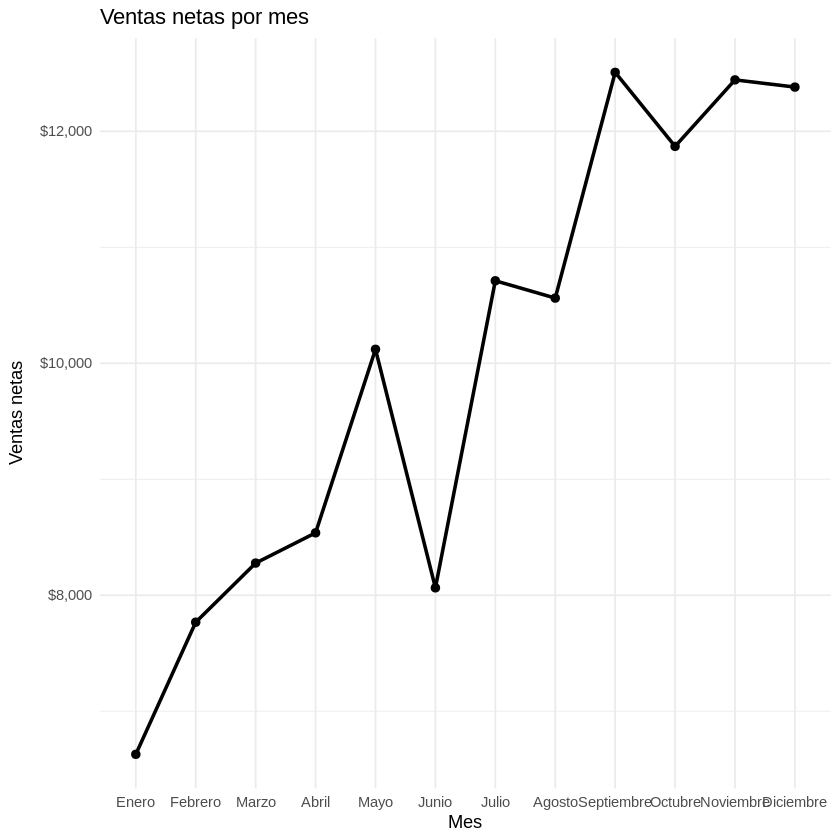

In [9]:
# Gráfica de ventas netas por mes

grafica_ventas_mes <- ggplot(resumen_mes, aes(x = reorder(Nombre_Mes, Mes), y = Ventas_Netas, group = 1)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  labs(
    title = "Ventas netas por mes",
    x = "Mes",
    y = "Ventas netas"
  ) +
  scale_y_continuous(labels = dollar_format(prefix = "$")) +
  theme_minimal()

print(grafica_ventas_mes)

## 9. Análisis por sucursal

Este apartado compara el desempeño de cada sucursal. Con esto se pueden detectar unidades fuertes y sucursales que requieren seguimiento.

In [10]:
# ============================================================
# 9. ANÁLISIS POR SUCURSAL
# ============================================================

resumen_sucursal <- ventas_modelo %>%
  group_by(Sucursal, Estado, Tamaño) %>%
  summarise(
    Ventas_Netas = sum(Importe_Neto, na.rm = TRUE),
    Transacciones = n_distinct(VentaID),
    Unidades = sum(Cantidad, na.rm = TRUE),
    Ticket_Promedio = Ventas_Netas / Transacciones,
    .groups = "drop"
  ) %>%
  arrange(desc(Ventas_Netas))

print(resumen_sucursal)

# A tibble: 5 × 7
  Sucursal     Estado Tamaño Ventas_Netas Transacciones Unidades Ticket_Promedio
  <chr>        <chr>  <chr>         <dbl>         <int>    <dbl>           <dbl>
1 León Plaza … Guana… Grande       31909.           301      533           106. 
2 Querétaro C… Queré… Grande       30353.           329      542            92.3
3 San Juan de… Queré… Media…       23078.           220      392           105. 
4 Celaya Plaz… Guana… Media…       21760.           224      389            97.1
5 Aguascalien… Aguas… Peque…       12771.           126      233           101. 


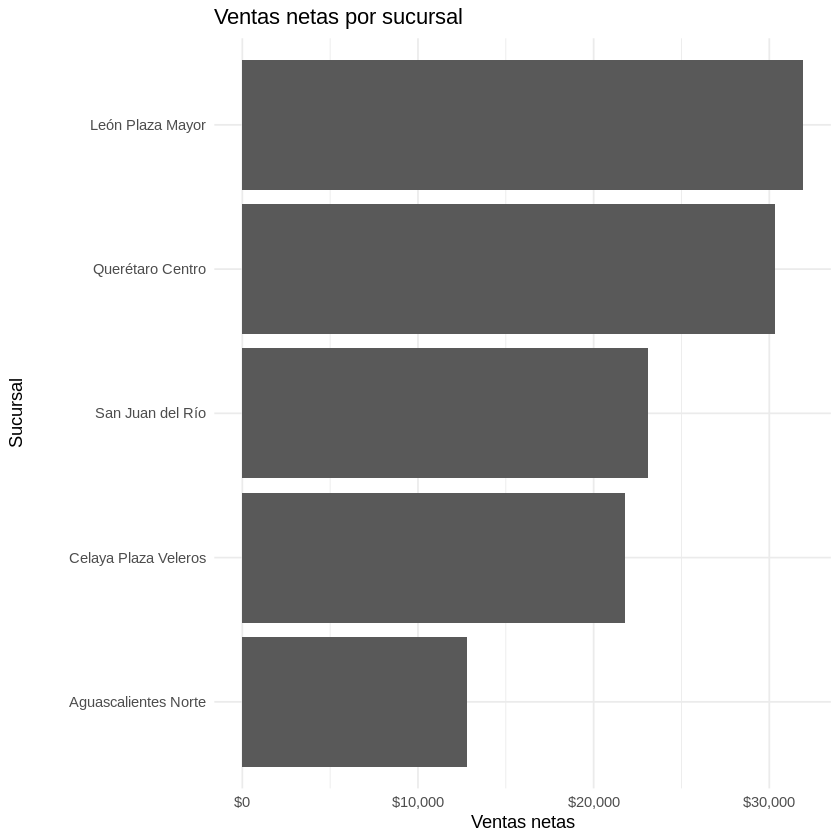

In [11]:
# Gráfica de ventas por sucursal

grafica_sucursal <- ggplot(resumen_sucursal, aes(x = reorder(Sucursal, Ventas_Netas), y = Ventas_Netas)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Ventas netas por sucursal",
    x = "Sucursal",
    y = "Ventas netas"
  ) +
  scale_y_continuous(labels = dollar_format(prefix = "$")) +
  theme_minimal()

print(grafica_sucursal)

## 10. Análisis por categoría y producto

Aquí se identifica qué categorías y productos generan mayor venta. Esto ayuda a tomar decisiones sobre inventario, promociones y surtido.

In [12]:
# ============================================================
# 10. ANÁLISIS POR CATEGORÍA
# ============================================================

resumen_categoria <- ventas_modelo %>%
  group_by(Categoria) %>%
  summarise(
    Ventas_Netas = sum(Importe_Neto, na.rm = TRUE),
    Unidades = sum(Cantidad, na.rm = TRUE),
    Transacciones = n_distinct(VentaID),
    .groups = "drop"
  ) %>%
  mutate(
    Participacion = Ventas_Netas / sum(Ventas_Netas)
  ) %>%
  arrange(desc(Ventas_Netas))

print(resumen_categoria)

# A tibble: 5 × 5
  Categoria     Ventas_Netas Unidades Transacciones Participacion
  <chr>                <dbl>    <dbl>         <int>         <dbl>
1 Sándwiches          33057.      325           191         0.276
2 Café                32171.      659           371         0.268
3 Repostería          22003.      519           300         0.184
4 Bebidas Frías       20426.      326           186         0.170
5 Té                  12215       260           152         0.102


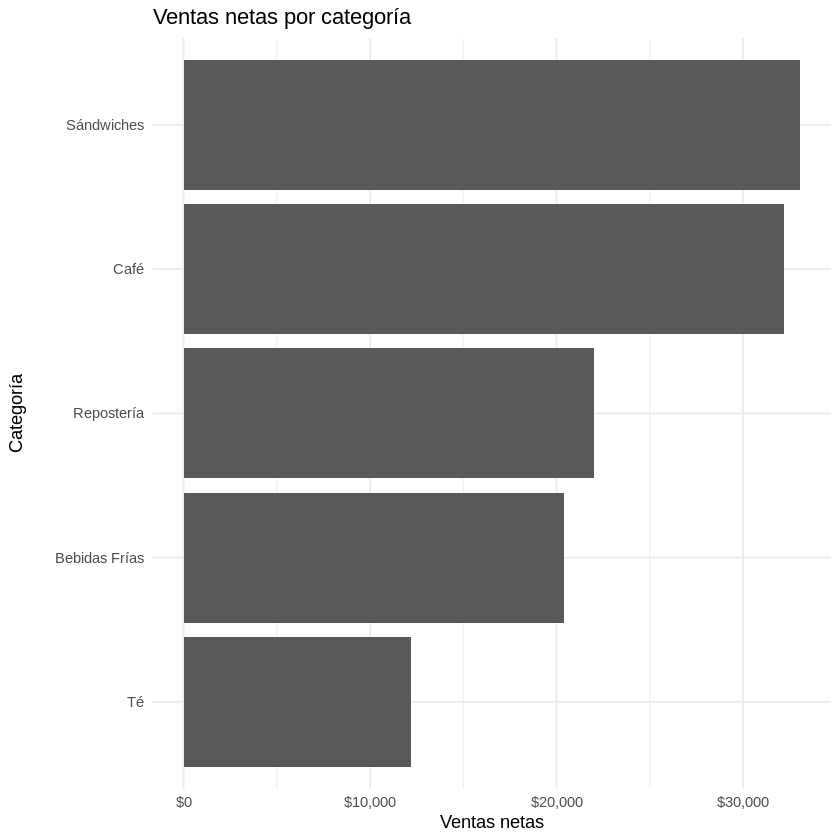

In [13]:
# Gráfica de ventas por categoría

grafica_categoria <- ggplot(resumen_categoria, aes(x = reorder(Categoria, Ventas_Netas), y = Ventas_Netas)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Ventas netas por categoría",
    x = "Categoría",
    y = "Ventas netas"
  ) +
  scale_y_continuous(labels = dollar_format(prefix = "$")) +
  theme_minimal()

print(grafica_categoria)

In [14]:
# ============================================================
# 11. ANÁLISIS POR PRODUCTO
# ============================================================

resumen_producto <- ventas_modelo %>%
  group_by(Producto, Categoria) %>%
  summarise(
    Ventas_Netas = sum(Importe_Neto, na.rm = TRUE),
    Unidades = sum(Cantidad, na.rm = TRUE),
    Transacciones = n_distinct(VentaID),
    .groups = "drop"
  ) %>%
  arrange(desc(Ventas_Netas))

cat("===== TOP 10 PRODUCTOS POR VENTAS =====\n")
print(head(resumen_producto, 10))

===== TOP 10 PRODUCTOS POR VENTAS =====
# A tibble: 10 × 5
   Producto               Categoria     Ventas_Netas Unidades Transacciones
   <chr>                  <chr>                <dbl>    <dbl>         <int>
 1 Bagel Salmón Ahumado   Sándwiches          13700       111            64
 2 Sándwich Pavo Manchego Sándwiches          11006.      118            75
 3 Frappé Café            Bebidas Frías        8512       123            71
 4 Wrap Pollo César       Sándwiches           8351.       96            52
 5 Cheesecake Rebanada    Repostería           7862.      123            71
 6 Frappé Chocolate       Bebidas Frías        7722       109            61
 7 Cappuccino             Café                 6900.      127            71
 8 Mocha                  Café                 6894.      114            66
 9 Latte                  Café                 6563.      115            64
10 Brownie                Repostería           4846.      109            57


## 11. Análisis de Pareto

El análisis de Pareto permite identificar los productos más importantes. La lógica es que una parte pequeña de productos suele generar una parte considerable de las ventas.

In [15]:
# ============================================================
# 12. ANÁLISIS DE PARETO DE PRODUCTOS
# ============================================================

pareto_productos <- resumen_producto %>%
  arrange(desc(Ventas_Netas)) %>%
  mutate(
    Participacion = Ventas_Netas / sum(Ventas_Netas),
    Acumulado = cumsum(Participacion),
    Clasificacion = if_else(Acumulado <= 0.80, "Prioritario", "Secundario")
  )

print(pareto_productos)

cat("\n===== PRODUCTOS PRIORITARIOS SEGÚN PARETO =====\n")
print(pareto_productos %>% filter(Clasificacion == "Prioritario"))

# A tibble: 20 × 8
   Producto          Categoria Ventas_Netas Unidades Transacciones Participacion
   <chr>             <chr>            <dbl>    <dbl>         <int>         <dbl>
 1 Bagel Salmón Ahu… Sándwich…       13700       111            64        0.114 
 2 Sándwich Pavo Ma… Sándwich…       11006.      118            75        0.0918
 3 Frappé Café       Bebidas …        8512       123            71        0.0710
 4 Wrap Pollo César  Sándwich…        8351.       96            52        0.0697
 5 Cheesecake Reban… Reposter…        7862.      123            71        0.0656
 6 Frappé Chocolate  Bebidas …        7722       109            61        0.0644
 7 Cappuccino        Café             6900.      127            71        0.0576
 8 Mocha             Café             6894.      114            66        0.0575
 9 Latte             Café             6563.      115            64        0.0547
10 Brownie           Reposter…        4846.      109            57        0.0404
11 Espres

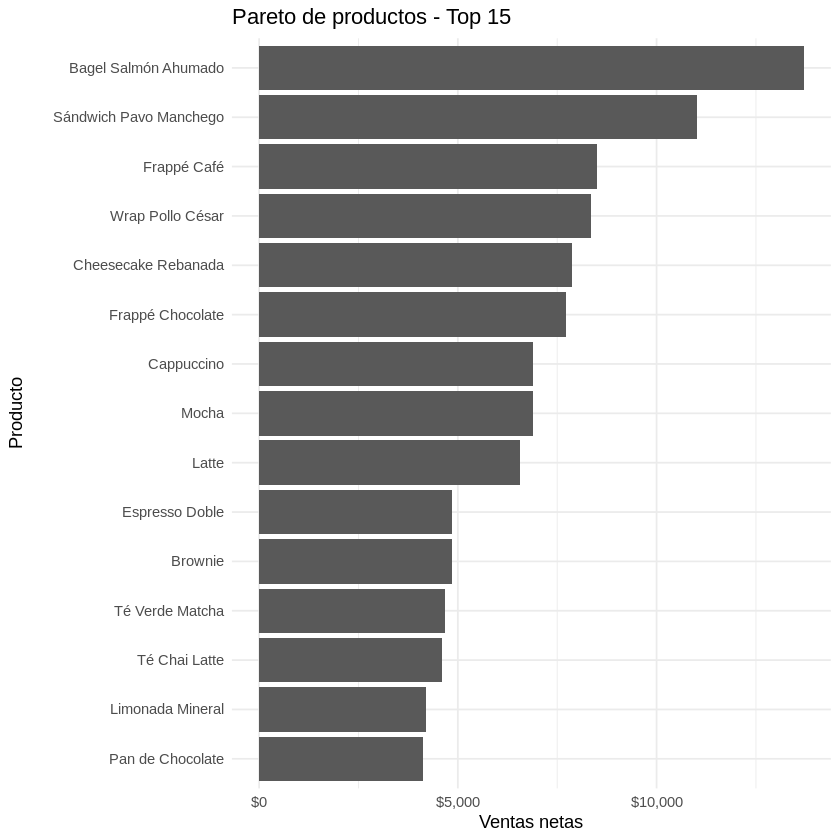

In [16]:
# Gráfica de Pareto con los principales productos

pareto_top <- pareto_productos %>%
  slice(1:15) %>%
  mutate(Producto = reorder(Producto, Ventas_Netas))

grafica_pareto <- ggplot(pareto_top, aes(x = Producto, y = Ventas_Netas)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Pareto de productos - Top 15",
    x = "Producto",
    y = "Ventas netas"
  ) +
  scale_y_continuous(labels = dollar_format(prefix = "$")) +
  theme_minimal()

print(grafica_pareto)

## 12. Cumplimiento de metas mensuales

En esta sección se comparan las ventas reales contra las metas. Esto permite evaluar si el desempeño comercial está por arriba o por debajo de lo planeado.

In [17]:
# ============================================================
# 13. ANÁLISIS DE METAS MENSUALES
# ============================================================

metas_mes <- metas_limpias %>%
  group_by(Año, Mes, Inicio_Mes) %>%
  summarise(
    Meta_Ventas = sum(Meta_Ventas, na.rm = TRUE),
    Meta_Transacciones = sum(Meta_Transacciones, na.rm = TRUE),
    .groups = "drop"
  )

ventas_metas <- resumen_mes %>%
  mutate(Inicio_Mes = as.Date(paste(Año, Mes, 1, sep = "-"))) %>%
  left_join(metas_mes, by = c("Año", "Mes", "Inicio_Mes")) %>%
  mutate(
    Cumplimiento_Meta = Ventas_Netas / Meta_Ventas,
    Diferencia_Meta = Ventas_Netas - Meta_Ventas,
    Estatus = case_when(
      Cumplimiento_Meta >= 1 ~ "Meta cumplida",
      Cumplimiento_Meta >= 0.90 ~ "Cerca de la meta",
      TRUE ~ "Por debajo de la meta"
    )
  )

print(ventas_metas)

# A tibble: 12 × 14
     Año   Mes Nombre_Mes Ventas_Netas Ventas_Brutas Transacciones Unidades
   <dbl> <dbl> <chr>             <dbl>         <dbl>         <int>    <dbl>
 1  2025     1 Enero             6629.          6733            67      124
 2  2025     2 Febrero           7768.          7911            74      140
 3  2025     3 Marzo             8277.          8408            85      153
 4  2025     4 Abril             8538.          8759            83      163
 5  2025     5 Mayo             10120.         10296           101      173
 6  2025     6 Junio             8064.          8189            93      141
 7  2025     7 Julio            10711.         10874           108      179
 8  2025     8 Agosto           10562.         10755           104      177
 9  2025     9 Septiembre       12508          12620           109      207
10  2025    10 Octubre          11870.         12076           119      202
11  2025    11 Noviembre        12443.         12548           130  

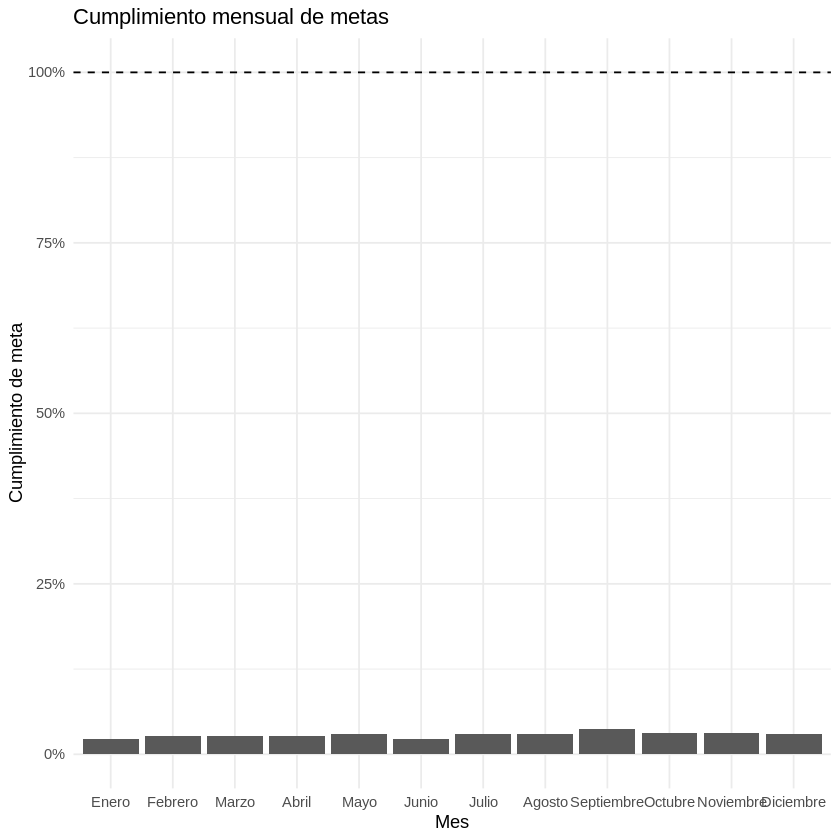

In [18]:
# Gráfica de cumplimiento de metas

grafica_metas <- ggplot(ventas_metas, aes(x = reorder(Nombre_Mes, Mes), y = Cumplimiento_Meta)) +
  geom_col() +
  geom_hline(yintercept = 1, linetype = "dashed") +
  labs(
    title = "Cumplimiento mensual de metas",
    x = "Mes",
    y = "Cumplimiento de meta"
  ) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  theme_minimal()

print(grafica_metas)

## 13. Encuesta de satisfacción

La encuesta permite relacionar variables de servicio con la satisfacción general. Esto ayuda a tomar decisiones orientadas a mejorar la experiencia del cliente.

In [19]:
# ============================================================
# 14. ANÁLISIS DE ENCUESTA DE SATISFACCIÓN
# ============================================================

resumen_encuesta <- encuesta_limpia %>%
  summarise(
    Encuestas = n(),
    Satisfaccion_Promedio = mean(Satisfaccion_General, na.rm = TRUE),
    Tiempo_Espera_Promedio = mean(Tiempo_Espera_Min, na.rm = TRUE),
    Calidad_Promedio = mean(Calidad_Producto, na.rm = TRUE),
    Atencion_Promedio = mean(Atencion_Personal, na.rm = TRUE),
    Limpieza_Promedio = mean(Limpieza, na.rm = TRUE),
    Precio_Promedio = mean(Precio_Percibido, na.rm = TRUE),
    Porcentaje_Recomienda = mean(Recomendaria == "Sí", na.rm = TRUE)
  )

print(resumen_encuesta)

# A tibble: 1 × 8
  Encuestas Satisfaccion_Promedio Tiempo_Espera_Promedio Calidad_Promedio
      <int>                 <dbl>                  <dbl>            <dbl>
1       100                  8.60                   7.17              7.3
# ℹ 4 more variables: Atencion_Promedio <dbl>, Limpieza_Promedio <dbl>,
#   Precio_Promedio <dbl>, Porcentaje_Recomienda <dbl>


In [20]:
# ============================================================
# 15. CORRELACIONES CON SATISFACCIÓN GENERAL
# ============================================================

correlaciones <- encuesta_limpia %>%
  summarise(
    Corr_Tiempo_Espera = cor(Tiempo_Espera_Min, Satisfaccion_General, use = "complete.obs"),
    Corr_Calidad = cor(Calidad_Producto, Satisfaccion_General, use = "complete.obs"),
    Corr_Atencion = cor(Atencion_Personal, Satisfaccion_General, use = "complete.obs"),
    Corr_Limpieza = cor(Limpieza, Satisfaccion_General, use = "complete.obs"),
    Corr_Precio = cor(Precio_Percibido, Satisfaccion_General, use = "complete.obs")
  )

print(correlaciones)

# A tibble: 1 × 5
  Corr_Tiempo_Espera Corr_Calidad Corr_Atencion Corr_Limpieza Corr_Precio
               <dbl>        <dbl>         <dbl>         <dbl>       <dbl>
1             -0.534        0.614         0.475         0.130      0.0520


`geom_smooth()` using formula = 'y ~ x'


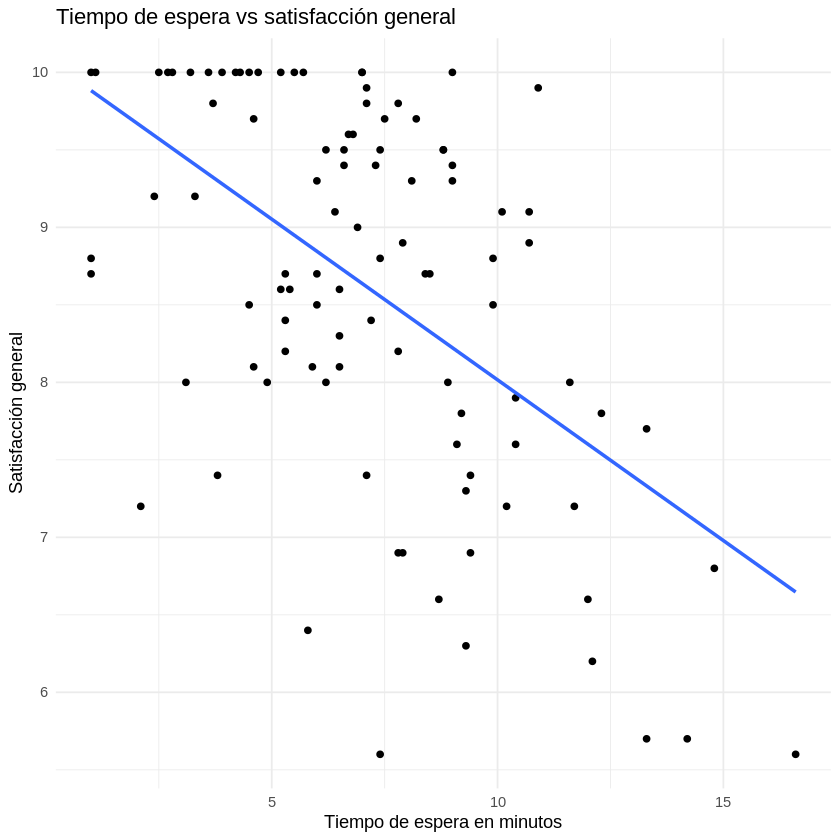

In [21]:
# Gráfica: tiempo de espera vs satisfacción general

grafica_espera <- ggplot(encuesta_limpia, aes(x = Tiempo_Espera_Min, y = Satisfaccion_General)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  labs(
    title = "Tiempo de espera vs satisfacción general",
    x = "Tiempo de espera en minutos",
    y = "Satisfacción general"
  ) +
  theme_minimal()

print(grafica_espera)

## 14. Modelo de regresión

El modelo de regresión sirve para identificar qué variables explican mejor la satisfacción general. No se usa para tomar una decisión automática, sino como apoyo analítico.

In [22]:
# ============================================================
# 16. MODELO DE REGRESIÓN PARA SATISFACCIÓN
# ============================================================

modelo_satisfaccion <- lm(
  Satisfaccion_General ~ Tiempo_Espera_Min + Calidad_Producto + Atencion_Personal + Limpieza + Precio_Percibido,
  data = encuesta_limpia
)

summary(modelo_satisfaccion)


Call:
lm(formula = Satisfaccion_General ~ Tiempo_Espera_Min + Calidad_Producto + 
    Atencion_Personal + Limpieza + Precio_Percibido, data = encuesta_limpia)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.69232 -0.30148  0.03917  0.34054  1.10013 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)        3.23017    0.51858   6.229 1.31e-08 ***
Tiempo_Espera_Min -0.19345    0.01682 -11.502  < 2e-16 ***
Calidad_Producto   0.39951    0.03204  12.470  < 2e-16 ***
Atencion_Personal  0.25426    0.02645   9.614 1.22e-15 ***
Limpieza           0.15378    0.04037   3.809 0.000249 ***
Precio_Percibido   0.13313    0.02999   4.440 2.45e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5195 on 94 degrees of freedom
Multiple R-squared:  0.8288,	Adjusted R-squared:  0.8197 
F-statistic: 91.02 on 5 and 94 DF,  p-value: < 2.2e-16


## 15. Simulación Monte Carlo

La simulación Monte Carlo se utiliza para analizar decisiones bajo incertidumbre. En lugar de usar un solo valor fijo, se simulan distintos escenarios posibles de ventas, costos variables y costos fijos.

In [23]:
# ============================================================
# 17. SIMULACIÓN MONTE CARLO
# ============================================================

# Función para simular una distribución triangular.
# Se usa cuando se tiene valor mínimo, más probable y máximo.
rtriang <- function(n, min, mode, max){
  u <- runif(n)
  c <- (mode - min) / (max - min)
  ifelse(
    u < c,
    min + sqrt(u * (max - min) * (mode - min)),
    max - sqrt((1 - u) * (max - min) * (max - mode))
  )
}

set.seed(42)

n_sim <- 10000

ventas_2026 <- rnorm(n_sim, mean = 1200000, sd = 150000)
costo_variable_pct <- runif(n_sim, min = 0.38, max = 0.48)
costos_fijos <- rtriang(n_sim, min = 280000, mode = 310000, max = 340000)
tasa_impuesto <- 0.30

simulacion <- tibble(
  Ventas = ventas_2026,
  Costo_Variable_Pct = costo_variable_pct,
  Costos_Fijos = costos_fijos,
  Utilidad_Neta = (Ventas - Ventas * Costo_Variable_Pct - Costos_Fijos) * (1 - tasa_impuesto)
)

resumen_simulacion <- simulacion %>%
  summarise(
    Utilidad_Media = mean(Utilidad_Neta),
    Probabilidad_Mayor_300k = mean(Utilidad_Neta > 300000),
    Probabilidad_Perdida = mean(Utilidad_Neta < 0),
    IC_95_Inferior = quantile(Utilidad_Neta, 0.025),
    IC_95_Superior = quantile(Utilidad_Neta, 0.975)
  )

print(resumen_simulacion)

# A tibble: 1 × 5
  Utilidad_Media Probabilidad_Mayor_300k Probabilidad_Perdida IC_95_Inferior
           <dbl>                   <dbl>                <dbl>          <dbl>
1        261099.                   0.275                    0        135812.
# ℹ 1 more variable: IC_95_Superior <dbl>


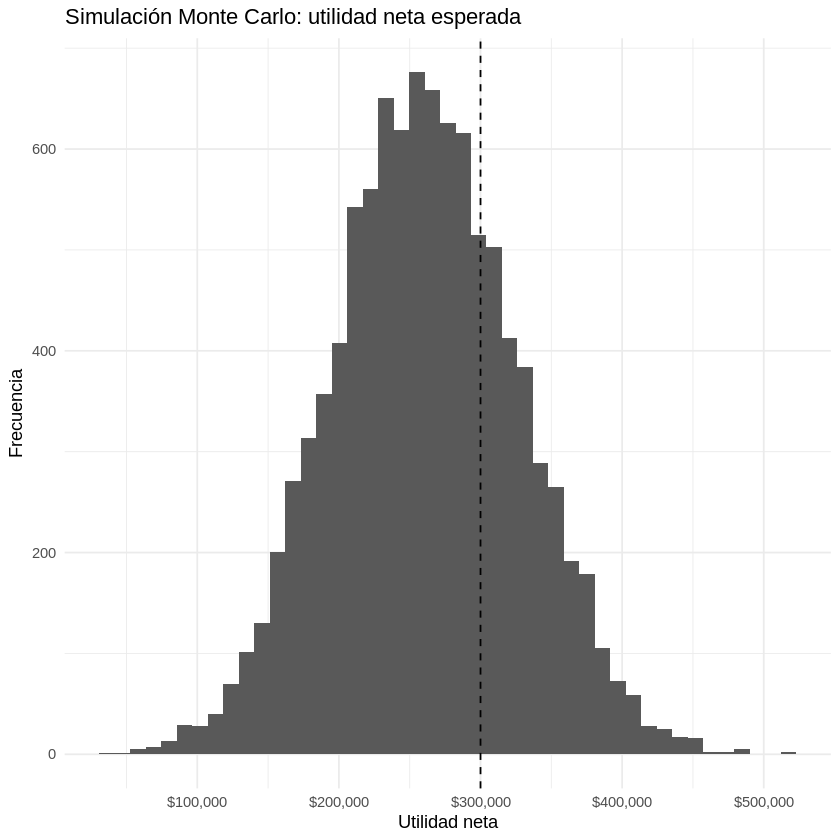

In [24]:
# Gráfica de simulación Monte Carlo

grafica_montecarlo <- ggplot(simulacion, aes(x = Utilidad_Neta)) +
  geom_histogram(bins = 45) +
  geom_vline(xintercept = 300000, linetype = "dashed") +
  labs(
    title = "Simulación Monte Carlo: utilidad neta esperada",
    x = "Utilidad neta",
    y = "Frecuencia"
  ) +
  scale_x_continuous(labels = dollar_format(prefix = "$")) +
  theme_minimal()

print(grafica_montecarlo)

## 16. Guardar gráficas y resultados

Esta sección guarda las gráficas en formato PNG, las tablas en CSV y un archivo Excel con las principales tablas del análisis.

In [25]:
# ============================================================
# 18. EXPORTAR RESULTADOS
# ============================================================

if(!dir.exists("/content/graficas_unidad5")){
  dir.create("/content/graficas_unidad5")
}

ggsave("/content/graficas_unidad5/ventas_por_mes.png", grafica_ventas_mes, width = 8, height = 4.5)
ggsave("/content/graficas_unidad5/ventas_por_sucursal.png", grafica_sucursal, width = 8, height = 4.5)
ggsave("/content/graficas_unidad5/ventas_por_categoria.png", grafica_categoria, width = 8, height = 4.5)
ggsave("/content/graficas_unidad5/pareto_productos.png", grafica_pareto, width = 8, height = 5)
ggsave("/content/graficas_unidad5/cumplimiento_metas.png", grafica_metas, width = 8, height = 4.5)
ggsave("/content/graficas_unidad5/espera_satisfaccion.png", grafica_espera, width = 8, height = 4.5)
ggsave("/content/graficas_unidad5/montecarlo_utilidad.png", grafica_montecarlo, width = 8, height = 4.5)

write_csv(resumen_mes, "/content/resumen_mes.csv")
write_csv(resumen_sucursal, "/content/resumen_sucursal.csv")
write_csv(resumen_categoria, "/content/resumen_categoria.csv")
write_csv(resumen_producto, "/content/resumen_producto.csv")
write_csv(pareto_productos, "/content/pareto_productos.csv")
write_csv(ventas_metas, "/content/ventas_metas.csv")
write_csv(simulacion, "/content/simulacion_montecarlo.csv")

resultados_excel <- list(
  "KPIs_Generales" = kpis_generales,
  "Resumen_Mes" = resumen_mes,
  "Resumen_Sucursal" = resumen_sucursal,
  "Resumen_Categoria" = resumen_categoria,
  "Resumen_Producto" = resumen_producto,
  "Pareto_Productos" = pareto_productos,
  "Ventas_vs_Metas" = ventas_metas,
  "Resumen_Encuesta" = resumen_encuesta,
  "Correlaciones" = correlaciones,
  "Monte_Carlo" = resumen_simulacion
)

write_xlsx(resultados_excel, "/content/resultados_practica_unidad5.xlsx")

cat("Resultados guardados correctamente.\n")
cat("Revisa la carpeta /content/graficas_unidad5 y el archivo /content/resultados_practica_unidad5.xlsx\n")

`geom_smooth()` using formula = 'y ~ x'


Resultados guardados correctamente.
Revisa la carpeta /content/graficas_unidad5 y el archivo /content/resultados_practica_unidad5.xlsx


## 17. Descargar resultados en ZIP

Ejecuta esta celda para crear un archivo comprimido con todos los resultados de la práctica.

In [26]:
# ============================================================
# 19. CREAR ZIP CON RESULTADOS
# ============================================================

archivos_zip <- c(
  "/content/graficas_unidad5",
  "/content/resumen_mes.csv",
  "/content/resumen_sucursal.csv",
  "/content/resumen_categoria.csv",
  "/content/resumen_producto.csv",
  "/content/pareto_productos.csv",
  "/content/ventas_metas.csv",
  "/content/simulacion_montecarlo.csv",
  "/content/resultados_practica_unidad5.xlsx"
)

zip(
  zipfile = "/content/resultados_unidad5_DDDM.zip",
  files = archivos_zip
)

cat("Archivo ZIP creado: /content/resultados_unidad5_DDDM.zip\n")
cat("Para descargarlo, búscalo en el panel izquierdo de archivos de Colab.\n")

Archivo ZIP creado: /content/resultados_unidad5_DDDM.zip
Para descargarlo, búscalo en el panel izquierdo de archivos de Colab.


## 18. Conclusión general

La práctica permitió aplicar el proceso de toma de decisiones basada en datos a partir de una base comercial. Primero se recopilaron y limpiaron los datos; después se organizaron en un modelo que relaciona ventas, productos, sucursales, clientes, vendedores, calendario y metas. Con esta información fue posible construir indicadores clave como ventas netas, unidades vendidas, ticket promedio, cumplimiento de metas y participación por categoría.

El uso de R fue útil porque permitió realizar el análisis de forma ordenada y reproducible. Cada paso quedó documentado mediante código, por lo que el procedimiento puede repetirse con nuevos datos sin empezar desde cero. Además, R facilitó la creación de resúmenes, gráficas, análisis de Pareto, correlaciones, regresión y simulación Monte Carlo.

En general, la práctica muestra que los datos ayudan a reducir la toma de decisiones basada únicamente en intuición. Al observar tendencias, comparar sucursales, revisar productos prioritarios y medir la satisfacción del cliente, se pueden proponer acciones concretas para mejorar ventas, servicio e inventario.

## 19. Conclusiones específicas

**Conclusión sobre ventas:**  
El análisis de ventas por mes permite observar el comportamiento comercial a lo largo del año. Esta información ayuda a identificar periodos fuertes y débiles, lo cual es útil para planear promociones, compras e inventario.

**Conclusión sobre sucursales:**  
La comparación por sucursal permite detectar qué puntos de venta tienen mejor desempeño y cuáles necesitan seguimiento. Esto puede apoyar decisiones sobre capacitación, metas, inventario y estrategias locales.

**Conclusión sobre productos:**  
El análisis por categoría y producto permite conocer qué artículos generan mayor valor para el negocio. Con el Pareto se identifican productos prioritarios que deben recibir mayor atención en inventario, disponibilidad y promoción.

**Conclusión sobre metas:**  
La comparación entre ventas reales y metas permite evaluar si el negocio está cumpliendo lo planeado. Cuando una meta no se cumple, el análisis ayuda a detectar dónde se debe intervenir.

**Conclusión sobre satisfacción del cliente:**  
La encuesta ayuda a relacionar la experiencia del cliente con variables como tiempo de espera, calidad, atención, limpieza y precio percibido. Esto permite tomar decisiones enfocadas en mejorar el servicio.

**Conclusión sobre incertidumbre:**  
La simulación Monte Carlo permitió observar distintos escenarios posibles de utilidad. Esta herramienta es importante porque no se queda con un solo resultado, sino que muestra un rango de posibilidades y ayuda a anticipar riesgos.

In [27]:
# ============================================================
# 20. INFORMACIÓN FINAL DE LA SESIÓN
# ============================================================

sessionInfo()

R version 4.6.0 (2026-04-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] writexl_1.5.4   scales_1.4.0    lubridate_1.9.5 forcats_1.0.1  
 [5] stringr_1.6.0   dplyr_1.2.1     purrr_1.2.2     readr_2.2.0    
 [9] tidyr_1.3.2     tibble_3.3.1    ggpl